<div style="background-color:#E8F8F5; padding:12px; border-left:5px solid #1ABC9C; border-radius:10px; margin:10px 0; line-height:1.5;">
  <h2 style="color:#1ABC9C; margin-top:0;">🎯 EDA Goals</h2>


  <ol style="margin:0; padding-left:20px; color:#117864; font-size:14px;">
    <li><strong>Data Overview:</strong> Assess data quality by checking for missing values, duplicates, and reviewing basic statistical summaries.</li>
    <li><strong>Feature Understanding:</strong> Analyze numerical and categorical features using descriptive statistics (mean, median) and distribution analysis (histograms, KDE, skewness).</li>
    <li><strong>Outlier Analysis:</strong> Identify and analyze outliers in numerical features (e.g., BMI) using the IQR method and visualize them with boxplots, without removing them.</li>
    <li><strong>Target Analysis:</strong> Examine the distribution of the target variable <code>diagnosed_diabetes</code> and assess class balance.</li>
    <li><strong>Correlation Analysis:</strong> Identify relationships between numerical features and their correlation with the target variable.</li>
    <li><strong>Group-Based Analysis:</strong> Explore how diabetes prevalence varies across different groups (e.g., income level, gender, education level, smoking status, and family history).</li>
    <li><strong>Interactive Exploration:</strong> Provide interactive visualizations to explore feature distributions across different groups (e.g., BMI across income levels).</li>
    <li><strong>Insights Extraction:</strong> Summarize key patterns, trends, and anomalies discovered during the analysis.</li>
  </ol>

  <p style="margin-top:10px; font-size:12px; color:#117864;">
  ⚠️ <strong>Note:</strong> This analysis focuses on understanding the data and extracting meaningful insights. No predictive modeling or data transformations were applied, as the dataset distributions were already approximately balanced and suitable for interpretation.
  </p>


## 🔍 *Data Loading & Overview*

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv("/kaggle/input/competitions/playground-series-s5e12/train.csv")
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [3]:
df.isnull().sum().any(), df.duplicated().sum().any(), df.shape

(np.False_, np.False_, (700000, 26))

In [4]:
df.describe().drop(['id'], axis=1)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
obj_cols = df.select_dtypes("object").columns.tolist()
print(f"Categorical columns: \n{obj_cols}")

Categorical columns: 
['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


## *Balance Checking*

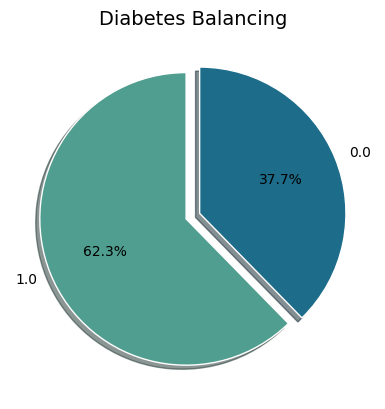

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = df['diagnosed_diabetes'].value_counts()
colors = sns.color_palette("crest", len(target_counts))

plt.figure(figsize=(4.75,4.75))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, 
        shadow=True, explode=[0.05]*len(target_counts), wedgeprops={'edgecolor':'white'})
plt.title("Diabetes Balancing", fontsize=14)
plt.show()

In [7]:
# mean-median of numerical features..

rows = []
for col in df.columns:
    if col not in obj_cols + ['id', 'diagnosed_diabetes']:
        rows.append({
            "Feature":  col,
            "Mean":  round(df[col].mean(), 2),
            "Median":  round(df[col].median(), 2)})

num_description = pd.DataFrame(rows)
num_description.sample(5)

,Feature,Mean,Median
4,sleep_hours_per_day,7.00,7.0
11,cholesterol_total,186.82,187.0
1,alcohol_consumption_per_week,2.07,2.0
3,diet_score,5.96,6.0
6,bmi,25.87,25.9


## 📈 *KPIs of BMI*

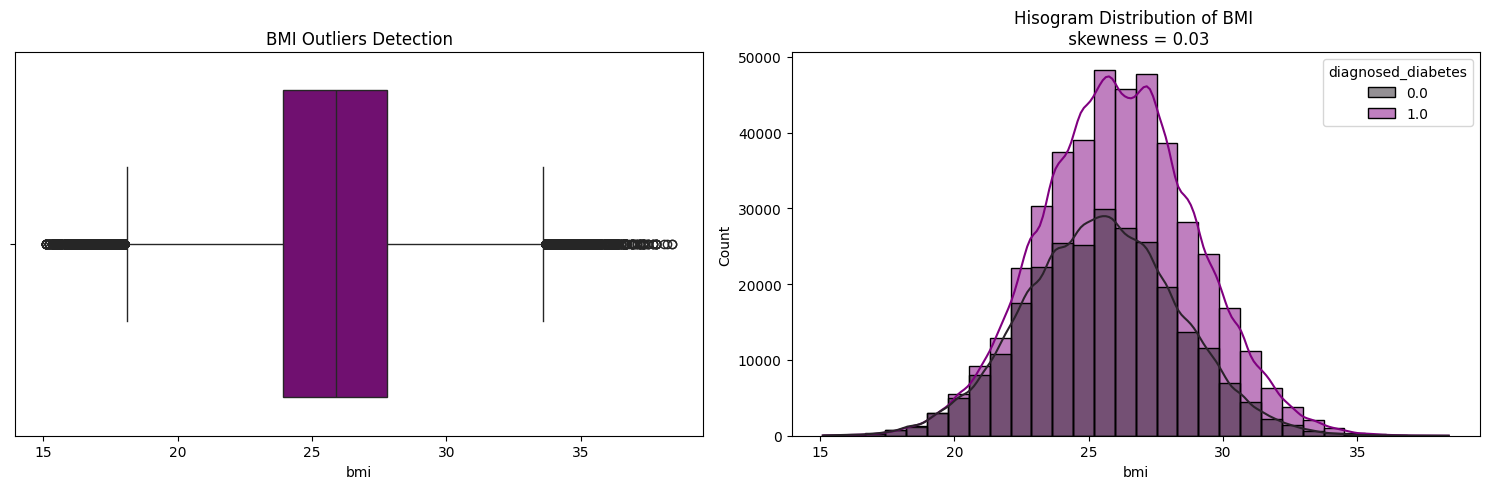

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
for i in range (2):
    if i==0:
        sns.boxplot(x=df['bmi'], ax=ax[i], color="purple")
        ax[i].set_title("BMI Outliers Detection")
    else:
        sns.histplot(data=df, x="bmi", hue="diagnosed_diabetes", ax=ax[i], kde=True, bins=30, palette="dark:purple")
        ax[i].set_title(f"Hisogram Distribution of BMI \n skewness = {df["bmi"].skew():.2f}")

plt.tight_layout()
plt.show()

In [9]:
def iqr_detection(df, col):
    Q1 = np.percentile(df[col], 25, method="midpoint")
    Q3 = np.percentile(df[col], 75, method="midpoint")
    IQR = Q3 - Q1
    Lower_bound = Q1 - 1.5*IQR
    Upper_bound = Q3 + 1.5*IQR

    Outliers_range = df[(df[col]< Lower_bound) | (df[col]> Upper_bound)]
    print(f"{"=*="*27}\n Outliers Range: [{Lower_bound:0.2f}, {Upper_bound:0.2f}] \n{"=*="*27}")
    return Outliers_range[["bmi", "diagnosed_diabetes"]].sample(5)


iqr_detection(df, "bmi")    

=*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*=
 Outliers Range: [18.05, 33.65] 
=*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*==*=


,bmi,diagnosed_diabetes
50968,34.3,1.0
516654,16.5,1.0
448053,34.6,1.0
472689,33.9,1.0
543156,34.2,1.0


##### *Outliers in BMI are likely real-world observations (e.g., obesity cases), **not data errors**, so they were retained for analysis.*
##### *No transformation was applied since the distribution is already approximately normal*

## *Statistical Correlations with Diabetes "Target"*

In [10]:
num_cols = [t for t in df.columns if t not in obj_cols + ['diagnosed_diabetes']]
df[num_cols].corrwith(df['diagnosed_diabetes']).sort_values(ascending=False).head(6)

family_history_diabetes    0.211064
age                        0.161162
systolic_bp                0.107132
bmi                        0.105580
ldl_cholesterol            0.102771
triglycerides              0.090635
dtype: float64

## *Most High Multi-Collinearity*

In [11]:
correlation = df.select_dtypes(include="number").corr()
high_corr = correlation[((correlation > 0.5)|(correlation < -0.5)) & (correlation!= 1)]

high_corr_pairs = high_corr.stack().reset_index()
high_corr_pairs.columns = ['Column1', 'Column2', 'Correlation']

high_corr_pairs = high_corr_pairs[high_corr_pairs['Column1'] < high_corr_pairs['Column2']]

print(high_corr_pairs)

             Column1             Column2  Correlation
0                age         systolic_bp     0.502894
1                bmi  waist_to_hip_ratio     0.757191
4  cholesterol_total     ldl_cholesterol     0.805909


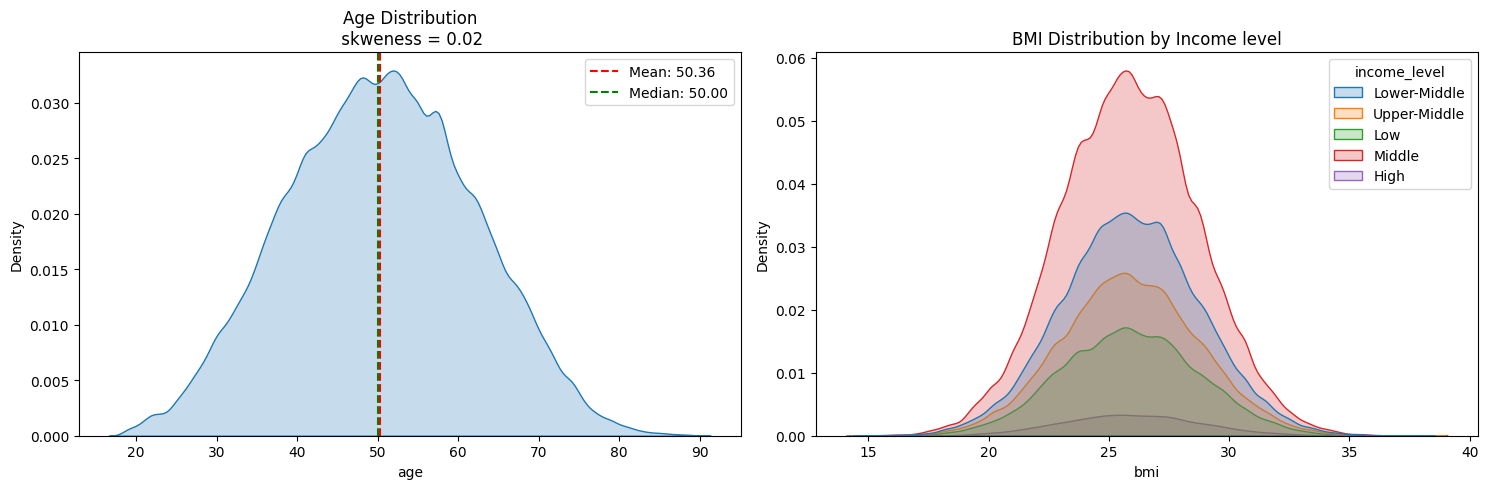

In [12]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
for i,col in enumerate(['age', 'bmi']):
    if i==0:
        sns.kdeplot(x=df[col], ax=ax[i], fill=True)
        ax[i].axvline(x=df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        ax[i].axvline(x=df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
        ax[i].set_title(f"Age Distribution\n skweness = {df[col].skew():.2f}")
        ax[i].legend()
    else:
        sns.kdeplot(data=df, x='bmi', hue='income_level', ax=ax[i], fill=True)
        ax[i].set_title("BMI Distribution by Income level")

plt.tight_layout()
plt.show()

## 📊 *Categorical Analysis*

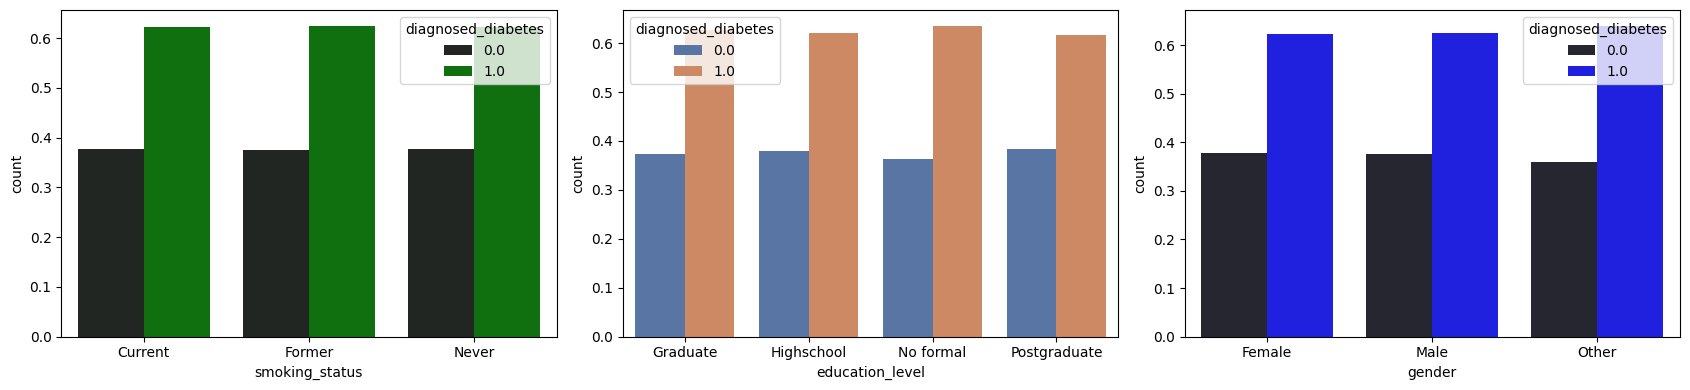

In [13]:
smok_diagnostic = (df.groupby("smoking_status")["diagnosed_diabetes"].value_counts(normalize=True).reset_index(name="count"))
education_diagnostic = (df.groupby("education_level")["diagnosed_diabetes"].value_counts(normalize=True).reset_index(name="count"))
gender_diagnostic = (df.groupby("gender")["diagnosed_diabetes"].value_counts(normalize=True).reset_index(name="count"))

fig, ax = plt.subplots(1,3, figsize=(17,4))
sns.barplot(data=smok_diagnostic, x="smoking_status", y="count", ax=ax[0], hue="diagnosed_diabetes", palette="dark:green")
sns.barplot(data=education_diagnostic, x="education_level", y="count", ax=ax[1], hue="diagnosed_diabetes", palette="deep")
sns.barplot(data=gender_diagnostic, x="gender", y="count", ax=ax[2], hue="diagnosed_diabetes", palette="dark:blue")


plt.tight_layout()
plt.show()

In [14]:
comb_analyizer = df.groupby(['smoking_status', 'education_level', 'gender'])['diagnosed_diabetes'].value_counts()
comb_analyizer

smoking_status  education_level  gender  diagnosed_diabetes
Current         Graduate         Female  1.0                   12582
                                         0.0                    7594
                                 Male    1.0                   11595
                                         0.0                    6804
                                 Other   1.0                     122
                                                               ...  
Never           Postgraduate     Female  0.0                   11193
                                 Male    1.0                   16456
                                         0.0                   10306
                                 Other   1.0                     184
                                         0.0                      81
Name: count, Length: 72, dtype: int64

## 📊 *Income Level KPIs & Impact of Family History on Diabetes Prevalence*

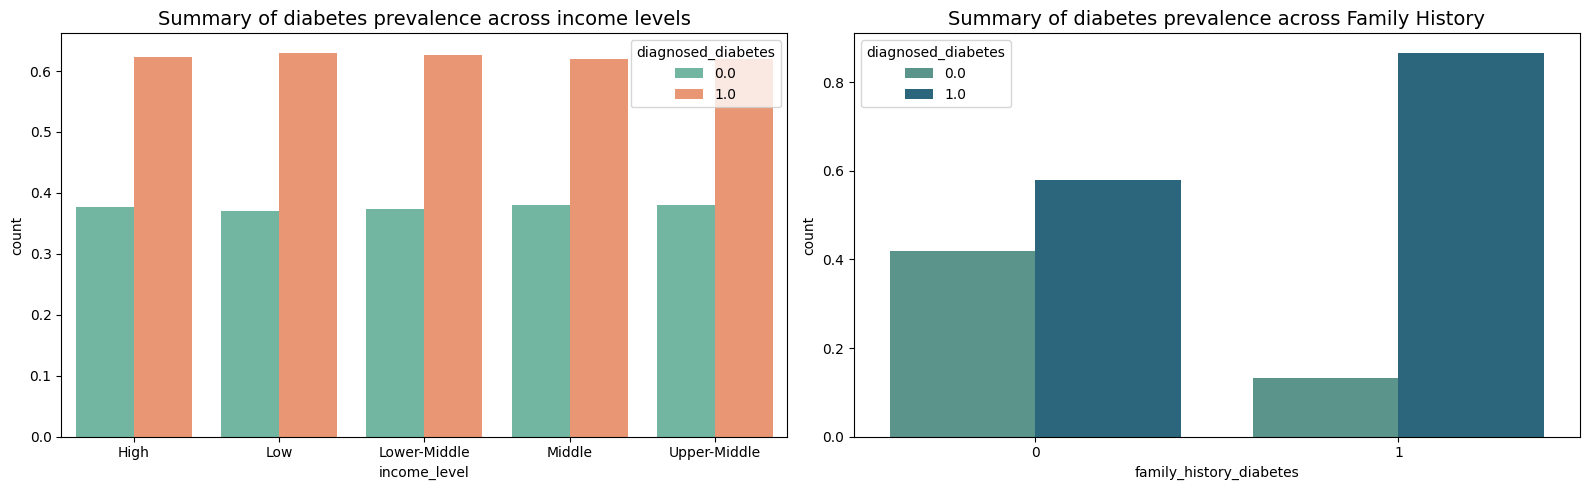

In [15]:
import plotly.graph_objects as go

income_diagnostic = df.groupby("income_level")['diagnosed_diabetes'].value_counts(normalize=True).reset_index(name="count")
family_his_diagnostic = df.groupby("family_history_diabetes")['diagnosed_diabetes'].value_counts(normalize=True).reset_index(name="count")

fig, ax = plt.subplots(1,2,figsize=(16,5))
sns.barplot(data=income_diagnostic, x="income_level", y="count", ax=ax[0], hue="diagnosed_diabetes", palette="Set2")
ax[0].set_title("Summary of diabetes prevalence across income levels", fontsize=14)

sns.barplot(data=family_his_diagnostic, x="family_history_diabetes", y="count", ax=ax[1], hue="diagnosed_diabetes", palette="crest")
ax[1].set_title("Summary of diabetes prevalence across Family History", fontsize=14)


plt.tight_layout()
plt.show()

<div style="background-color:#E8F8F5; padding:12px; border-left:5px solid #1ABC9C; border-radius:10px; margin:10px 0; line-height:1.5;">

  <h2 style="color:#1ABC9C; margin-top:0;">🏁 Conclusion & Key Insights</h2>
  
  <ol style="margin:0; padding-left:20px; color:#117864; font-size:14px;">
    <li><strong>Data Quality:</strong> The dataset is clean, with no missing values or duplicate records detected.</li>
    <li><strong>Numerical Features:</strong> Most numerical features exhibit approximately symmetric distributions. The BMI feature shows very low skewness (~0.03) with a few outliers, which were retained as valid real-world observations.</li>
    <li><strong>Categorical Features:</strong> Variables such as gender, education level, and smoking status show no significant variation in diabetes prevalence across their respective groups.</li>
    <li><strong>Family History:</strong> Individuals with a family history of diabetes demonstrate a higher likelihood of being diagnosed with diabetes, highlighting it as the most influential feature in this analysis.</li>
    <li><strong>Target Distribution:</strong> The target variable <code>diagnosed_diabetes</code> is relatively balanced, ensuring fair representation of both classes.</li>
    <li><strong>Correlations:</strong> No feature exhibits a strong linear correlation with the target variable, except for family history, which shows a moderate positive relationship.</li>
  </ol>

<div style="background-color:#E8F8F5; padding:12px; border-left:5px solid #1ABC9C; border-radius:8px; margin:10px 0; line-height:1.5;">
  <p style="margin-top:10px; font-size:13px; color:#117864;">
    🧠 <strong>Overall Insight:</strong><br>
    The dataset is well-structured and balanced, with minimal data quality issues. Among all features analyzed, <strong>family history</strong> stands out as the only variable with a meaningful impact on diabetes occurrence, aligning with real-world medical expectations. Other features show limited individual influence on the target variable.
  </p>

  <p style="margin-top:10px; font-size:13px; color:#117864;">
    ⚠️ <strong>Note:</strong><br>
    This analysis focuses on data understanding and insight extraction. No transformations or predictive modeling techniques were applied, as the data distributions were already suitable for interpretation.
  </p>

</div>